#Experiment 6: Sequential Models – RNN, LSTM, GRU

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Parameters
seq_length = 50  # The "memory" distance
input_size = 1
hidden_size = 32
epochs = 200

def generate_data(num_samples, length):
    # Random sequences
    X = np.random.standard_normal((num_samples, length, 1))
    # The target is just the first value of the sequence (Long dependency)
    y = X[:, 0, :]
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_train, y_train = generate_data(1000, seq_length)

In [2]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]) # Predict using the last hidden state

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

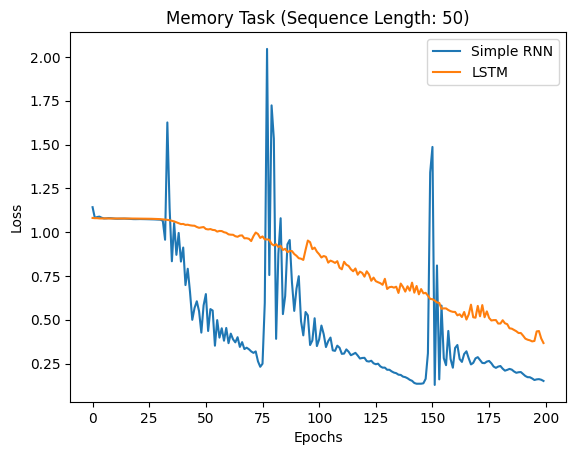

In [3]:
def train_model(model, X, y):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for epoch in range(epochs):
        outputs = model(X)
        loss = criterion(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

rnn_model = SimpleRNN(input_size, hidden_size)
lstm_model = SimpleLSTM(input_size, hidden_size)

rnn_losses = train_model(rnn_model, X_train, y_train)
lstm_losses = train_model(lstm_model, X_train, y_train)

plt.plot(rnn_losses, label='Simple RNN')
plt.plot(lstm_losses, label='LSTM')
plt.title(f'Memory Task (Sequence Length: {seq_length})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [4]:
class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # GRU combines forget and input gates into a single "update gate"
        self.gru = nn.ModuleList([nn.GRU(input_size, hidden_size, batch_first=True)])
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # PyTorch GRU returns (output, hidden)
        out, _ = self.gru[0](x)
        return self.fc(out[:, -1, :])

# Initialize and train
gru_model = SimpleGRU(input_size, hidden_size)
gru_losses = train_model(gru_model, X_train, y_train)

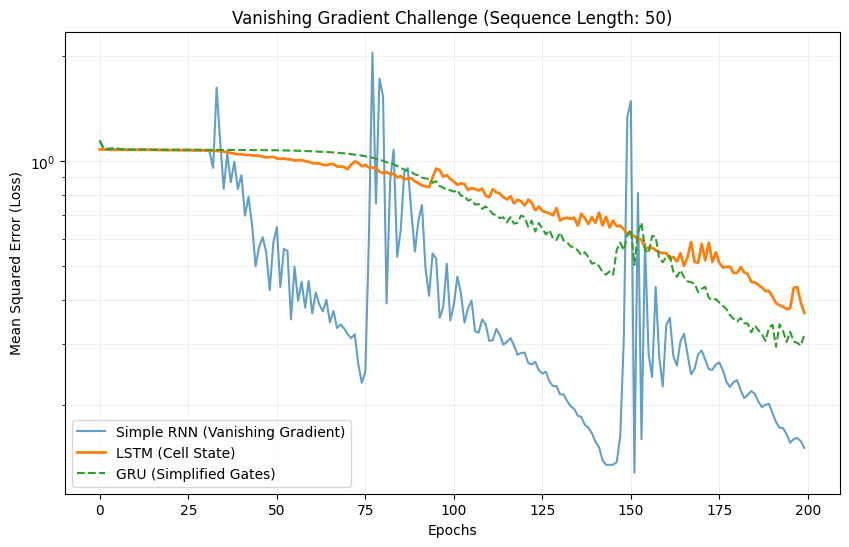

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(rnn_losses, label='Simple RNN (Vanishing Gradient)', alpha=0.7)
plt.plot(lstm_losses, label='LSTM (Cell State)', linewidth=2)
plt.plot(gru_losses, label='GRU (Simplified Gates)', linestyle='--')

plt.title(f'Vanishing Gradient Challenge (Sequence Length: {seq_length})')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Loss)')
plt.yscale('log') # Log scale helps see the difference when loss is small
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()